In [1]:
import pickle
import pandas as pd
import numpy as np
import plotly.express as px
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import umap.umap_ as umap
import musical
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm

In [38]:
labels_fn='/home/dg204/projects/rsignatures/data/processed/pcawg_labels.csv'
# see RFD_SigPlots
if labels_fn!=None:
    pb_labels = pd.read_csv(labels_fn, index_col=0)
    pb_labels.shape

    

In [39]:
meta_df = pd.read_csv('~/park_dglodzik//data_repo/PanCan/timing//icgc_sample_annotations_summary_table.txt', sep='\t')

In [40]:
meta_df.head(1)

,histology_abbreviation,icgc_sample_id,purity,ploidy,wgd_status,purity_conf_mad,num_subclones,num_clonal_snvs,num_subclonal_snvs,num_clonal_indels,...,donor_age_at_diagnosis,tumour_stage,tumour_grade,first_therapy_type,first_therapy_response,specimen_donor_treatment_type,cov_tumour,cov_normal,nrpcc,is_preferred
0,Biliary-AdenoCA,SA501461,0.36,1.982,no_wgd,0.001,0,9051.0,0.0,434.0,...,84.0,2,NaN,NaN,NaN,no treatment,31.2065,24.2542,5.635,True


In [41]:
pb_labels_m = pd.merge(pb_labels, meta_df[['tumour_aliquot_id', 'histology_abbreviation']], left_index=True, right_on='tumour_aliquot_id')

In [42]:
pb_labels.shape

(538, 3)

In [43]:
pb_labels_m.head(1)

,label,HRDetect,HRD_label,tumour_aliquot_id,histology_abbreviation
201,other,0.006313,HRP,fc8130e0-aed2-bb2f-e040-11ac0d485e12,Breast-AdenoCA


In [44]:
dataset='pancan_nonclust'


In [45]:
def fitSignatures(pkl_file, X_file, force_solution=None):
    # ----------------- Load model -----------------
    with open(pkl_file, 'rb') as f:
        model_loaded = pickle.load(f)
    
    if force_solution==None:
        deNovoSigs = pd.DataFrame(model_loaded.W)
        H_sel = pd.DataFrame(model_loaded.H.T)
        sil_scores = model_loaded.sil_score
    else:
        deNovoSigs = pd.DataFrame(model_loaded.W_all[force_solution])
        sil_scores = model_loaded.sil_score_all[force_solution]
        H_sel = pd.DataFrame(model_loaded.H_all[force_solution].T)
    
    deNovoSigs.columns = [f"Signature {i+1}" for i in range(deNovoSigs.shape[1])]
    H_sel.columns = [f"Signature {i+1}" for i in range(deNovoSigs.shape[1])]
    H_sel.index = model_loaded.samples
    sil_scores_dict = dict(zip([f"Signature {i+1}" for i in range(deNovoSigs.shape[1])], sil_scores))
    
    
    
    X = pd.read_csv(X_file, index_col=0)
    colnames_sel = [c for c in model_loaded.features if 'non-clustered' in c]
    X = X.loc[[c for c in colnames_sel if c in X.index],]
    deNovoSigs.index = model_loaded.features
    H, model = musical.refit.refit(X, deNovoSigs, method='likelihood_bidirectional', thresh=0.001)
    return H, deNovoSigs


In [46]:
pkl_file = '/home/dg204/park_dglodzik/svig/extractionLogs/SV_SigExtraction_nmf_RFD_non_clustered_replitime_pancan_sel.pkl'
X_file = '/home/dg204/projects/rsignatures/data/processed/SVmatrices/PCAWG/repliTiming_mp/Selected_repliTiming_mp.csv'

H_rt,deNovoSigs_rt = fitSignatures(pkl_file, X_file, force_solution=18)
deNovoSigs_rt.to_csv('/home/dg204/park_dglodzik/svig/extractionLogs/SV_SigExtraction_nmf_RFD_non_clustered_replitime_pancan_sel.signatures.csv')

In [47]:
pkl_file = '/home/dg204/park_dglodzik/svig/extractionLogs/SV_SigExtraction_nmf_RFD_non_clustered_pancan_sel.pkl'
X_file = '/home/dg204/projects/rsignatures/data/processed/SVmatrices/PCAWG/RFD/Selected_RFD.csv'
#output_dir = '/home/dg204/park_dglodzik/SVsigs/RT_pancan/'
H_rfd,deNovoSigs_rfd = fitSignatures(pkl_file, X_file)
deNovoSigs_rfd.to_csv('/home/dg204/park_dglodzik/svig/extractionLogs/SV_SigExtraction_nmf_RFD_non_clustered_pancan_sel.signatures.csv')

In [48]:
type(H_rfd)

pandas.core.frame.DataFrame

In [49]:
H_rfd.shape

(15, 631)

In [50]:
type(H_rt)

pandas.core.frame.DataFrame

In [51]:
H_rt.shape

(18, 631)

In [52]:
H_rfd.head()

,f39cc911-36a7-4c06-9e91-4ad86281db3d,e7dc7492-3a84-49c7-8dea-8f508b53dc40,8f558713-f32b-403b-aedf-c79efeb41c67,1eb62abc-7928-405b-84cc-f091ca5347b2,f9f04e42-63a2-4ee1-ade4-9e5bb5c20cdd,ec4d4cbc-d5d1-418d-a292-cad9576624fd,01658141-8398-4585-9f0f-8355dd9b0604,fc6d77a9-121b-48ab-a899-713c3d1319a2,07b5141f-ac79-439b-883b-b0183bbe7ff5,7b0b60c7-5fa0-440e-937f-8d82119330d6,...,706868b5-4920-433a-bea3-92e9bf83059b,b7a7d93b-38a7-4fc3-a433-3bb0a8cb7c42,2fe2433b-9a55-431f-a869-2b5a63e8e8fc,84e601b7-dfa5-4cd5-9fef-07f03967a0d4,9623d295-c23d-4f2f-827c-69f767a26f1f,b88f014e-bc0f-4775-8228-39e0b471c3b0,24badf07-8615-48a3-8d6e-45c3d783f18d,7ac0b303-d685-4fa5-bfec-34d2ba1dbc8e,ad41f1f3-e38e-4418-9c16-52bca5719f39,48f68f73-3ac0-44ac-ba12-b8889fcb7f38
Signature 1,0.00000,0.908210,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,2.809996,0.0,...,2.637836,0.000000,0.898552,2.746873,0.000000,0.000000,0.000000,1.666444,0.000000,2.167806
Signature 2,0.00000,2.979995,0.000000,6.616634,0.0,0.000000,5.576065,15.701696,0.795663,0.0,...,2.634804,2.555071,2.830881,9.939133,18.525289,2.455106,0.000000,5.023489,1.153379,5.083924
Signature 3,0.00000,0.000000,0.000000,0.000000,0.0,2.505718,0.000000,6.540282,0.000000,0.0,...,0.789475,0.000000,0.000000,0.000000,0.000000,1.418201,0.000000,0.000000,0.000000,0.000000
Signature 4,0.00000,0.000000,2.571985,4.186359,0.0,0.000000,0.000000,53.537192,3.939747,0.0,...,2.612332,0.000000,1.377338,9.204265,12.019848,6.841394,0.000000,10.464665,5.181870,1.354501
Signature 5,1.19062,0.000000,27.114027,6.866204,0.0,4.672866,52.657256,3.558253,6.234787,0.0,...,25.017642,17.083569,10.955565,7.917360,2.645012,9.559722,2.896048,21.862827,14.704855,9.992561


In [53]:
H_rt.head()

,f39cc911-36a7-4c06-9e91-4ad86281db3d,e7dc7492-3a84-49c7-8dea-8f508b53dc40,8f558713-f32b-403b-aedf-c79efeb41c67,1eb62abc-7928-405b-84cc-f091ca5347b2,f9f04e42-63a2-4ee1-ade4-9e5bb5c20cdd,ec4d4cbc-d5d1-418d-a292-cad9576624fd,01658141-8398-4585-9f0f-8355dd9b0604,fc6d77a9-121b-48ab-a899-713c3d1319a2,07b5141f-ac79-439b-883b-b0183bbe7ff5,7b0b60c7-5fa0-440e-937f-8d82119330d6,...,706868b5-4920-433a-bea3-92e9bf83059b,b7a7d93b-38a7-4fc3-a433-3bb0a8cb7c42,2fe2433b-9a55-431f-a869-2b5a63e8e8fc,84e601b7-dfa5-4cd5-9fef-07f03967a0d4,9623d295-c23d-4f2f-827c-69f767a26f1f,b88f014e-bc0f-4775-8228-39e0b471c3b0,24badf07-8615-48a3-8d6e-45c3d783f18d,7ac0b303-d685-4fa5-bfec-34d2ba1dbc8e,ad41f1f3-e38e-4418-9c16-52bca5719f39,48f68f73-3ac0-44ac-ba12-b8889fcb7f38
Signature 1,0.71489,1.857820,5.797750,4.399232,0.000000,0.000000,9.214267,0.892884,1.353906,0.600863,...,1.702305,0.000000,1.506134,9.913800,9.875270,13.662999,0.0,16.349743,2.394963,1.753320
Signature 2,0.00000,1.930942,0.638435,8.309598,1.599636,1.697452,1.913307,11.067145,0.912733,0.992573,...,0.506191,0.774686,2.896329,4.323765,0.741294,13.865268,0.0,13.593044,0.000000,0.000000
Signature 3,0.00000,0.000000,2.782776,5.534629,0.000000,2.661324,0.000000,17.770156,3.102906,0.000000,...,0.000000,0.000000,1.235373,0.000000,3.100217,0.000000,0.0,0.000000,0.000000,1.327322
Signature 4,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45.265719,2.109907,0.000000,...,3.403440,0.000000,0.000000,9.039931,8.585034,8.665995,0.0,9.217451,5.319153,0.000000
Signature 5,0.00000,0.000000,0.000000,6.277149,0.000000,0.000000,2.492585,0.000000,0.623914,0.000000,...,2.995819,2.802666,1.655143,6.466900,5.937176,0.196304,0.0,7.057905,1.371261,3.314619


In [54]:
H_rfd.index = H_rfd.index + '_RFD'
H_rt.index = H_rt.index + '_RT'

H_comb = pd.concat([H_rfd, H_rt], axis=0)
H_comb.to_csv('/home/dg204/projects/rsignatures/data/processed/H_comb.csv')

In [55]:
output_dir = '/home/dg204/park_dglodzik/SVsigs/umap_combined/'

In [56]:
figure_dir = '../../data/processed/Figures/Fig5/'

In [57]:
figure_dir

'../../data/processed/Figures/Fig5/'

/n/data1/hms/dbmi/park/dglodzik/envs/jupytervenv3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved Illustrator-editable PDF: /home/dg204/park_dglodzik/SVsigs/umap_combined//umap_projection_combined.pdf


<Figure size 1500x1500 with 0 Axes>

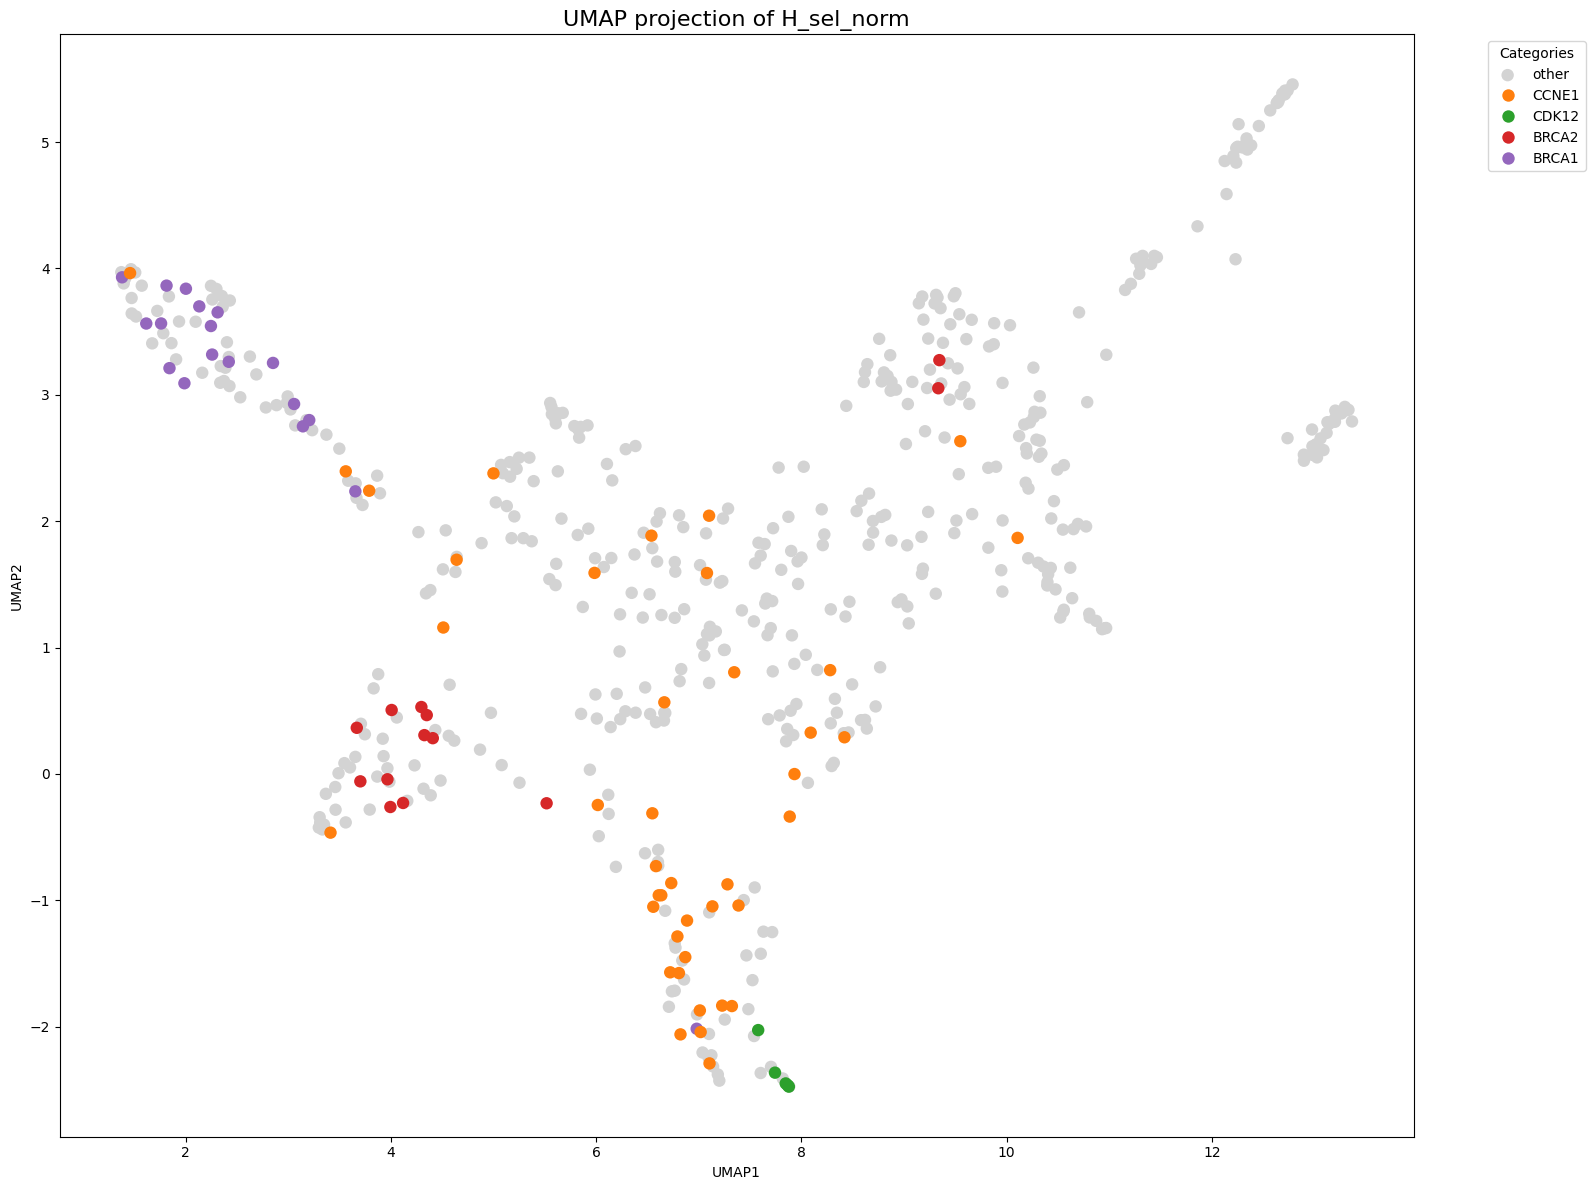

In [58]:
H_sel=H_comb.T
H_sel_norm = H_sel.div(H_sel.sum(axis=1), axis=0)
#H_sel_norm = H_sel
plt.figure(figsize=(15, 15))

# ✅ Make text editable in Illustrator
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
H_sel_norm = H_sel_norm.loc[[i for i in H_sel_norm.index if i in pb_labels.index],:]

# --- Label mapping ---
if labels_fn is not None:
    rowLabels = pb_labels.loc[H_sel_norm.index, 'label']
    unique_labels = rowLabels.unique()
    palette = sns.color_palette("tab10", len(unique_labels))
    lut = dict(zip(unique_labels, palette))
    row_colors = rowLabels.map(lut)
else:
    rowLabels = None

# --- Run UMAP ---
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    random_state=42
)
embedding = reducer.fit_transform(H_sel_norm)

# --- Create DataFrame ---
umap_df = pd.DataFrame(embedding, index=H_sel_norm.index, columns=['UMAP1', 'UMAP2'])
if rowLabels is not None:
    umap_df['label'] = rowLabels.values

# --- Plot ---
plt.figure(figsize=(16, 12))

if rowLabels is not None:
    # Split into "other" and "non-other"
    df_other = umap_df[umap_df['label'] == "other"]
    df_non_other = umap_df[umap_df['label'] != "other"]

    plt.scatter(
        df_other['UMAP1'],
        df_other['UMAP2'],
        s=80,
        facecolors='lightgray',
        edgecolors='none',
        linewidth=0.8,
        label='other',
        zorder=1
    )
    
    # Plot all non-"other" points on top
    sns.scatterplot(
        data=df_non_other,
        x='UMAP1',
        y='UMAP2',
        hue='label',
        palette={k: v for k, v in lut.items() if k != "other"},
        s=80,
        edgecolor='none',
        linewidth=0,
        legend=True,
        zorder=2
    )

    plt.legend(title="Categories", bbox_to_anchor=(1.05, 1), loc='upper left')

else:
    plt.scatter(umap_df['UMAP1'], umap_df['UMAP2'], s=50, color='grey')

plt.title("UMAP projection of H_sel_norm", fontsize=16)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.tight_layout()

# ✅ Save Illustrator-editable vector PDF
output_path = f"{output_dir}/umap_projection_combined.pdf"
plt.savefig(output_path, format='pdf')
print(f"Saved Illustrator-editable PDF: {output_path}")

plt.show()

In [59]:
H_rfd_norm = H_rfd.div(H_rfd.sum(axis=0), axis=1)
H_comb_norm  = H_comb.div(H_comb.sum(axis=0), axis=1)

Saved editable PDF: /home/dg204/park_dglodzik/SVsigs/umap_combined//signature_boxplots_all_vertical.pdf


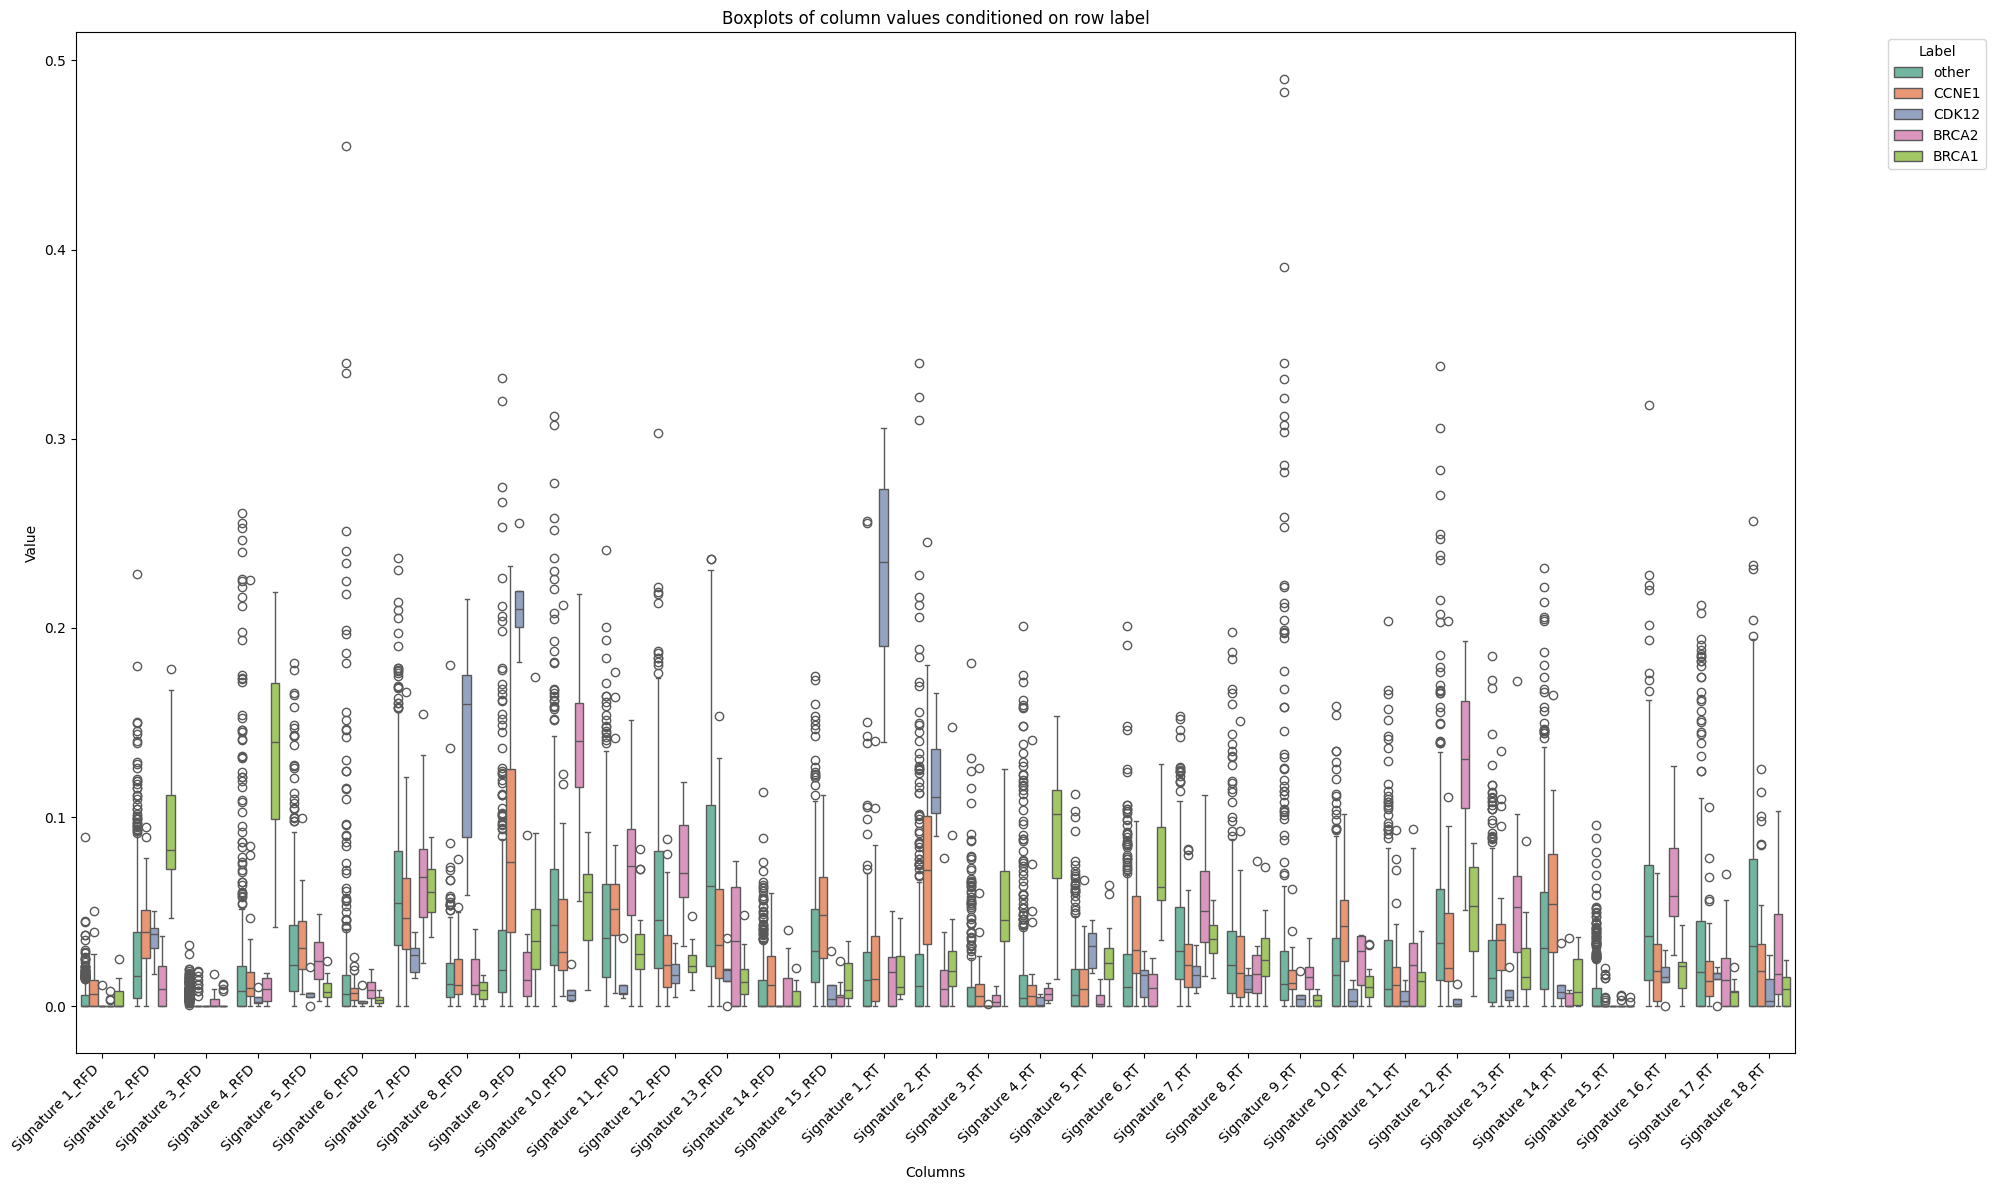

In [60]:
H_sel_norm = H_comb_norm.T
H_sel_norm=H_sel_norm[H_sel_norm.index.isin(pb_labels.index)]

if labels_fn!=None:
    rowLabels = pb_labels.loc[H_sel_norm.index, 'label']
    H_sel_labeled = H_sel_norm.copy()
    H_sel_labeled['label'] = rowLabels
    H_long = H_sel_labeled.melt(id_vars='label', var_name='column', value_name='value')
    
    plt.figure(figsize=(20, 12))
    
    sns.boxplot(
        data=H_long,
        x="column",         # Each column of H_sel
        y="value",          # Its numeric values
        hue="label",        # Conditioned on rowLabels
        palette="Set2"
    )
    
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Columns")
    plt.ylabel("Value")
    plt.title("Boxplots of column values conditioned on row label")
    plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    output_path = f"{output_dir}/signature_boxplots_all_vertical.pdf"
    plt.savefig(output_path, format="pdf")
    print(f"Saved editable PDF: {output_path}")
    plt.show()

Saved editable PDF: /home/dg204/park_dglodzik/SVsigs/umap_combined//signature_boxplots_all_vertical.pdf


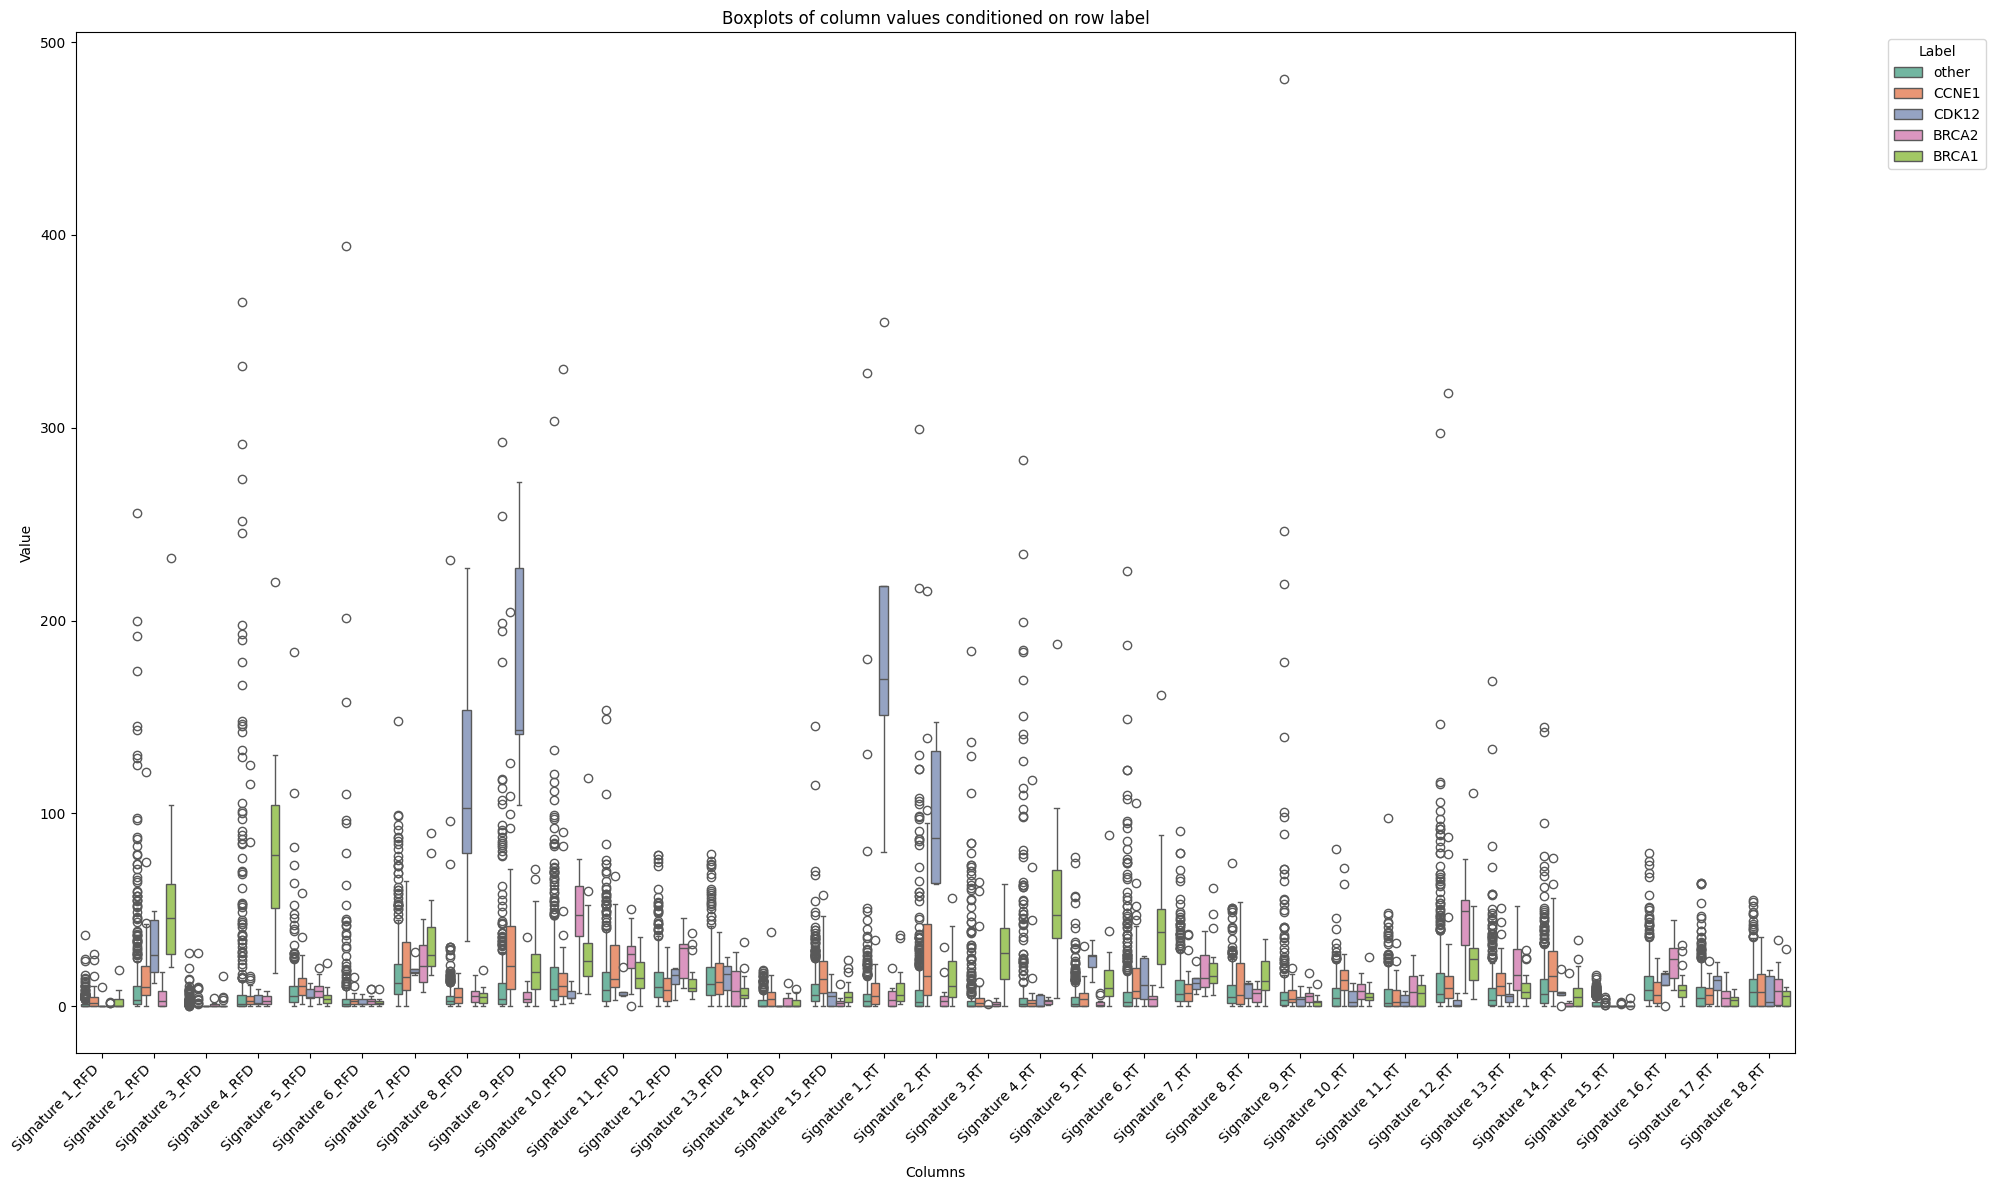

In [61]:
H_sel_norm = H_comb.T
H_sel_norm=H_sel_norm[H_sel_norm.index.isin(pb_labels.index)]

if labels_fn!=None:
    rowLabels = pb_labels.loc[H_sel_norm.index, 'label']
    H_sel_labeled = H_sel_norm.copy()
    H_sel_labeled['label'] = rowLabels
    H_long = H_sel_labeled.melt(id_vars='label', var_name='column', value_name='value')
    
    plt.figure(figsize=(20, 12))
    
    sns.boxplot(
        data=H_long,
        x="column",         # Each column of H_sel
        y="value",          # Its numeric values
        hue="label",        # Conditioned on rowLabels
        palette="Set2"
    )
    
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Columns")
    plt.ylabel("Value")
    plt.title("Boxplots of column values conditioned on row label")
    plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    output_path = f"{output_dir}/signature_boxplots_all_vertical.pdf"
    plt.savefig(output_path, format="pdf")
    print(f"Saved editable PDF: {output_path}")
    plt.show()

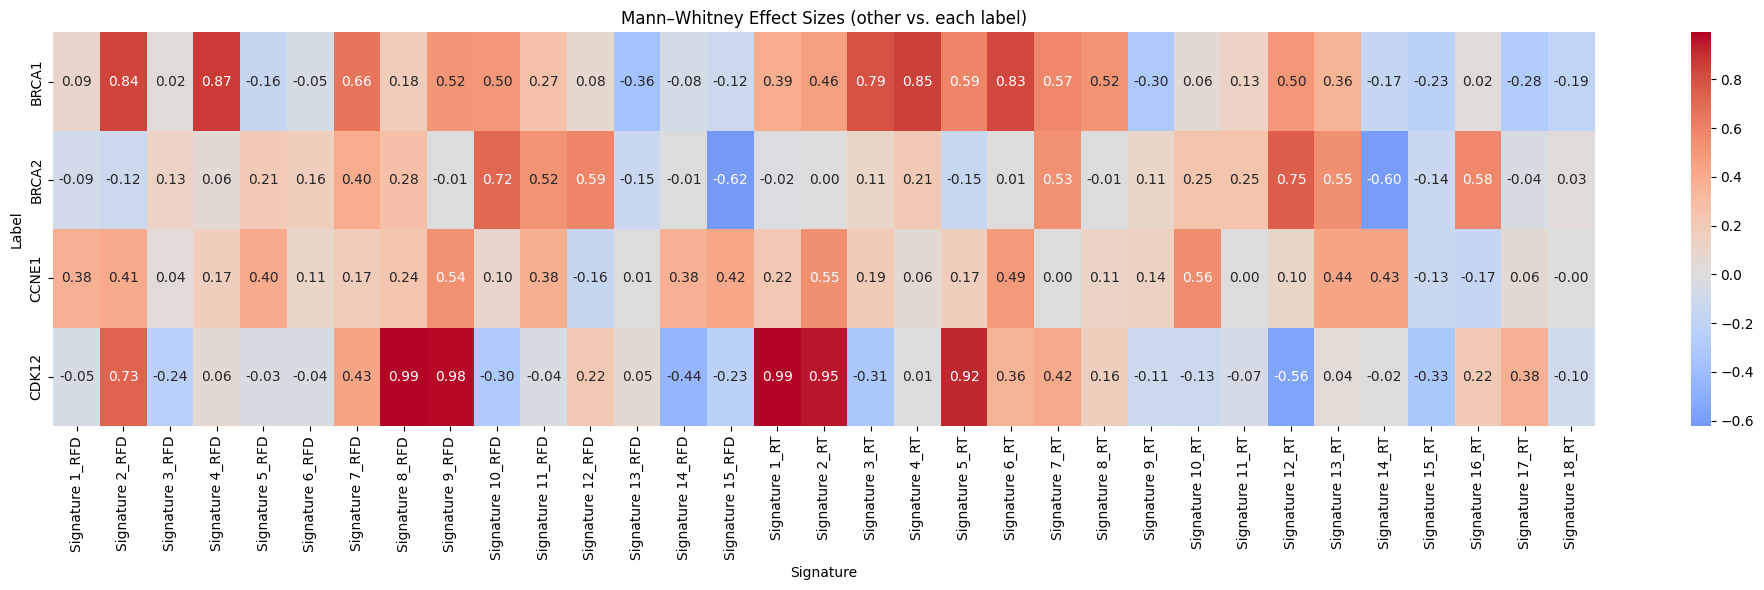

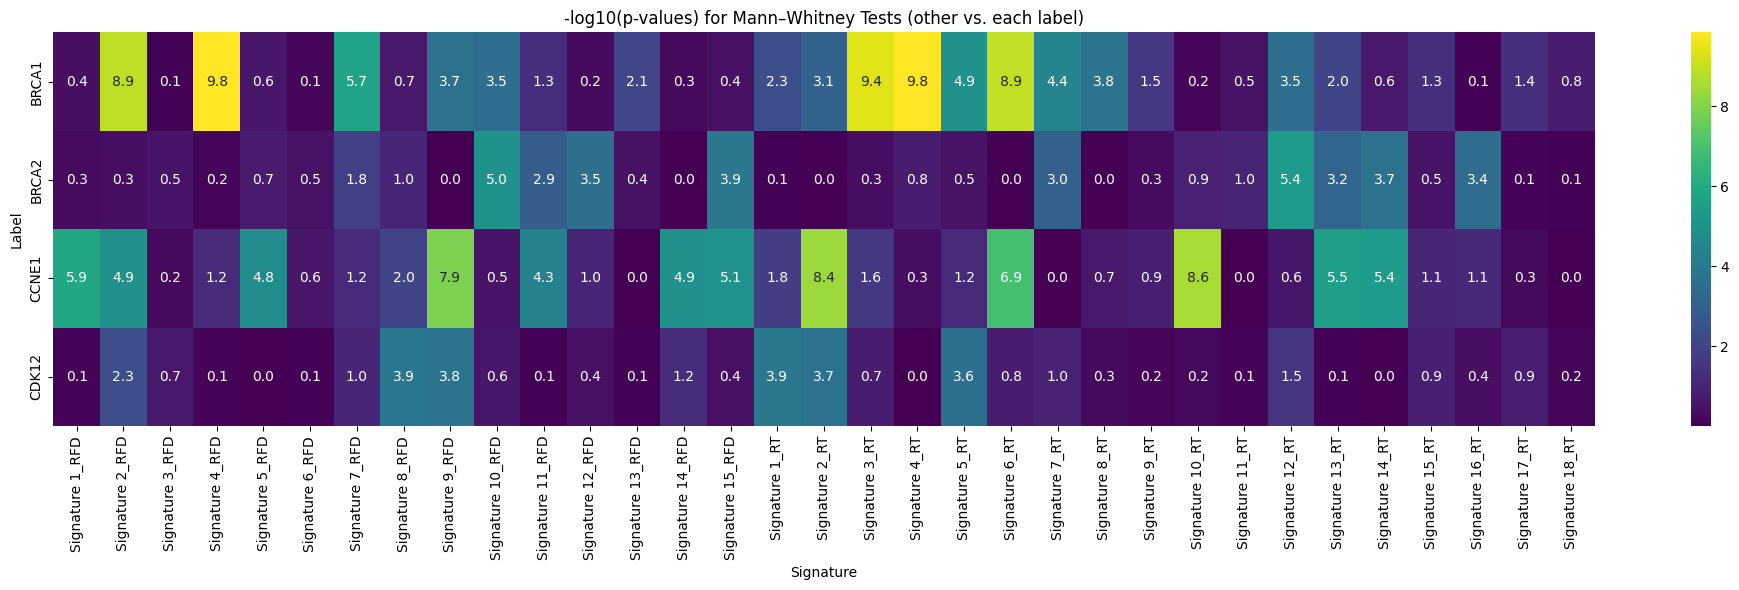

In [62]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
import seaborn as sns
import matplotlib.pyplot as plt

# --- define column order ---
col_order = [f"Signature {i}_RFD" for i in range(1, 16)]
col_order = H_comb.index


# make sure the column variable respects this order
H_long['column'] = pd.Categorical(H_long['column'], categories=col_order, ordered=True)

# --- run Mann–Whitney tests ---
results = []
for col in col_order:
    df_col = H_long[H_long['column'] == col]
    if df_col.empty:
        continue
    other_vals = df_col.loc[df_col['label'] == 'other', 'value']
    for lbl in df_col['label'].unique():
        if lbl == 'other':
            continue
        vals = df_col.loc[df_col['label'] == lbl, 'value']
        if len(other_vals) > 0 and len(vals) > 0:
            stat, p = mannwhitneyu(other_vals, vals, alternative='two-sided')
            n1, n2 = len(other_vals), len(vals)
            U = stat
            effect = 1 - (2 * U) / (n1 * n2)  # rank-biserial effect size
            results.append({'column': col, 'label': lbl, 'p': p, 'effect_size': effect})

results_df = pd.DataFrame(results)

# --- ensure consistent order before pivoting ---
results_df['column'] = pd.Categorical(results_df['column'], categories=col_order, ordered=True)
results_df = results_df.sort_values('column')

# --- pivot for heatmaps ---
p_pivot = results_df.pivot(index='label', columns='column', values='p')
effect_pivot = results_df.pivot(index='label', columns='column', values='effect_size')
p_log = -np.log10(p_pivot)

# --- plot effect sizes ---
plt.figure(figsize=(20, 6))
sns.heatmap(effect_pivot, cmap='coolwarm', center=0, annot=True, fmt=".2f")
plt.title("Mann–Whitney Effect Sizes (other vs. each label)")
plt.xlabel("Signature")
plt.ylabel("Label")
plt.tight_layout()
plt.show()

# --- plot p-values ---
plt.figure(figsize=(20, 6))
sns.heatmap(p_log, cmap='viridis', annot=True, fmt=".1f")
plt.title("-log10(p-values) for Mann–Whitney Tests (other vs. each label)")
plt.xlabel("Signature")
plt.ylabel("Label")
plt.tight_layout()
plt.show()


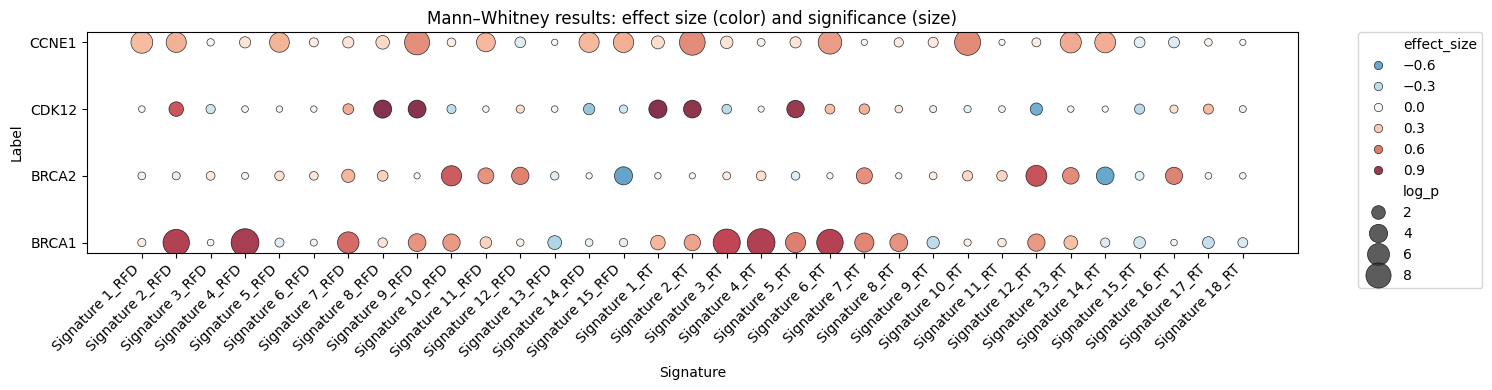

In [63]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- compute -log10(p) ---
results_df['log_p'] = -np.log10(results_df['p'])

# --- ensure ordered columns and labels ---
results_df['column'] = pd.Categorical(results_df['column'], categories=col_order, ordered=True)

vmax = np.nanmax(np.abs(results_df["effect_size"]))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

# --- plotting ---
plt.figure(figsize=(15, 4))

# Dot plot (bubble plot)
sns.scatterplot(
    data=results_df,
    x='column',
    y='label',
    size='log_p',                # bubble size ~ significance
    hue='effect_size',           # color ~ direction/magnitude
    palette="RdBu_r",      # diverging palette
    hue_norm=norm,         # <-- critical line
    edgecolor='black',
    sizes=(20, 400),             # adjust to taste
    linewidth=0.5,
    alpha=0.8
)

# Styling
plt.title("Mann–Whitney results: effect size (color) and significance (size)")
plt.xlabel("Signature")
plt.ylabel("Label")
plt.xticks(rotation=45, ha='right')

# Put legend for effect size and p-value
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()

op = f"{figure_dir}/Figure_sig_bubbleplot.pdf"
plt.savefig(op, format='pdf', dpi=300)

plt.show()

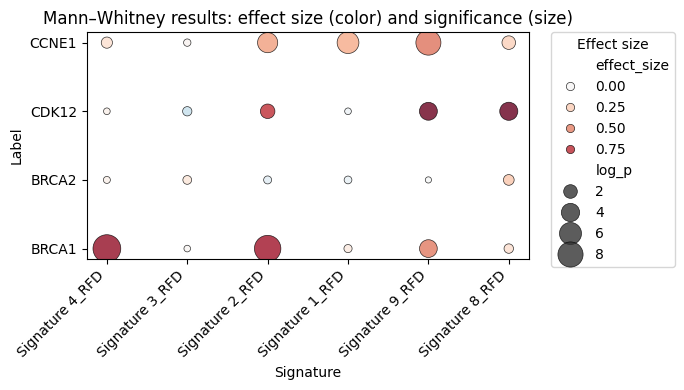

In [64]:
vmax = np.nanmax(np.abs(results_df["effect_size"]))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

# --- define desired order for x-axis ---
sig_order = ["Signature 4_RFD", "Signature 3_RFD", "Signature 2_RFD", "Signature 1_RFD", "Signature 9_RFD", "Signature 8_RFD"]

# --- compute -log10(p) ---
results_df['log_p'] = -np.log10(results_df['p'])

# --- filter and ensure order ---
results_df = results_df[results_df['column'].isin(sig_order)].copy()
results_df['column'] = pd.Categorical(results_df['column'], categories=sig_order, ordered=True)

# --- plotting ---
plt.figure(figsize=(7, 4))


sns.scatterplot(
    data=results_df,
    x="column",
    y="label",
    size="log_p",
    hue="effect_size",
    palette="RdBu_r",      # diverging palette
    hue_norm=norm,         # <-- critical line
    edgecolor="black",
    sizes=(20, 400),
    linewidth=0.5,
    alpha=0.8,
)
# --- styling ---
plt.title("Mann–Whitney results: effect size (color) and significance (size)")
plt.xlabel("Signature")
plt.ylabel("Label")
plt.xticks(rotation=45, ha='right')

# Put legend for effect size and p-value
plt.legend(
    title="Effect size",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0.
)
plt.tight_layout()

# --- save and show ---
output_path = f"{figure_dir}/Fig5_sig_bubbleplot_sel.pdf"
plt.savefig(output_path, format='pdf', dpi=300)
plt.show()

In [65]:
pb_labels_m['histology_abbreviation'].value_counts()

histology_abbreviation
Breast-AdenoCA      147
Prost-AdenoCA       127
Ovary-AdenoCA       106
Eso-AdenoCA          83
Lung-SCC             45
Lung-AdenoCA         25
Breast-LobularCA      5
Name: count, dtype: int64

In [66]:
H_sel=H_rfd.T
#H_sel = H_sel.loc[pb_labels_m.loc[pb_labels_m['histology_abbreviation']=='Breast-AdenoCA','tumour_aliquot_id']]
H_sel = H_sel.loc[pb_labels_m.loc[pb_labels_m['histology_abbreviation']=='Ovary-AdenoCA','tumour_aliquot_id']]
#H_sel = H_sel.loc[pb_labels_m.loc[pb_labels_m['histology_abbreviation']=='Eso-AdenoCA','tumour_aliquot_id']]
#H_sel = H_sel.loc[pb_labels_m.loc[pb_labels_m['histology_abbreviation']=='Lung-AdenoCA','tumour_aliquot_id']]

#H_sel = H_sel.loc[pb_labels_m.loc[pb_labels_m['histology_abbreviation']=='Prost-AdenoCA','tumour_aliquot_id']]

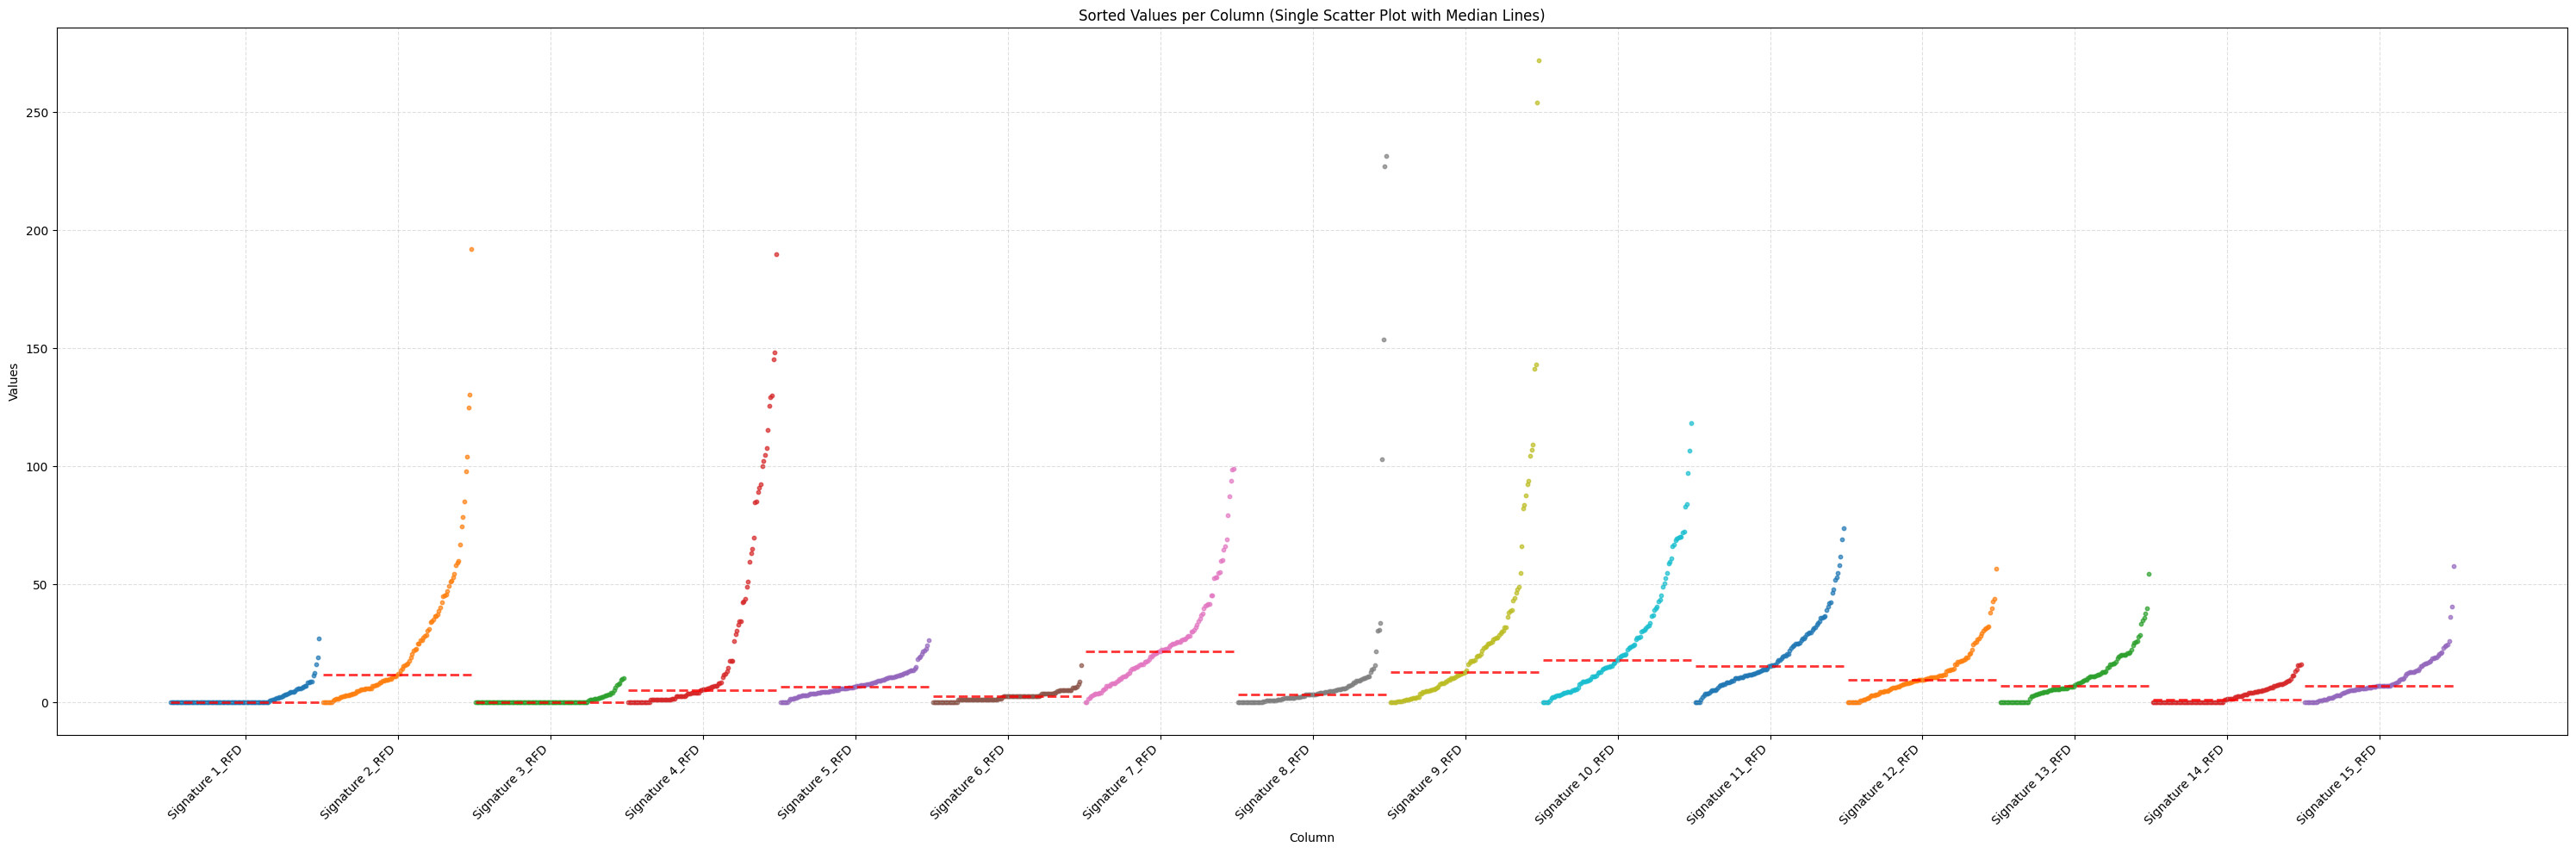

In [67]:
plt.figure(figsize=(30, 10))

start_idx = 0
tick_positions = []
tick_labels = []

for col in H_sel.columns:
    sorted_values = H_sel[col].sort_values().reset_index(drop=True)
    x_positions = range(start_idx, start_idx + len(sorted_values))
    
    # Plot points with smaller size
    plt.scatter(x_positions, sorted_values, label=col, alpha=0.7, s=10)
    
    # Add median line
    median_val = np.median(sorted_values)
    plt.hlines(median_val, start_idx, start_idx + len(sorted_values) - 1, 
               colors='red', linestyles='--', linewidth=2, alpha=0.8)
    
    # Save position for x-ticks (middle of section)
    tick_positions.append(start_idx + len(sorted_values) // 2)
    tick_labels.append(col)
    
    # Update start for next section
    start_idx += len(sorted_values) + 2  # +2 adds a small gap between sections

plt.xticks(tick_positions, tick_labels, rotation=45, ha='right')
plt.xlabel("Column")
plt.ylabel("Values")
plt.title("Sorted Values per Column (Single Scatter Plot with Median Lines)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [68]:
pb_labels.head()

,label,HRDetect,HRD_label
fc8130e0-aed2-bb2f-e040-11ac0d485e12,other,0.006313,HRP
fc8130e0-09f1-b964-e040-11ac0c48326e,other,0.000202,HRP
fc8130e0-0e1f-b54d-e040-11ac0c48326c,other,0.450404,HRP
fc8130e0-a774-d834-e040-11ac0c483268,other,0.001719,HRP
f7d70fac-c76f-399e-e040-11ac0c482f9c,other,0.001258,HRP


Saved editable PDF: /home/dg204/park_dglodzik/SVsigs/umap_combined//signature_boxplots_all_vertical.pdf


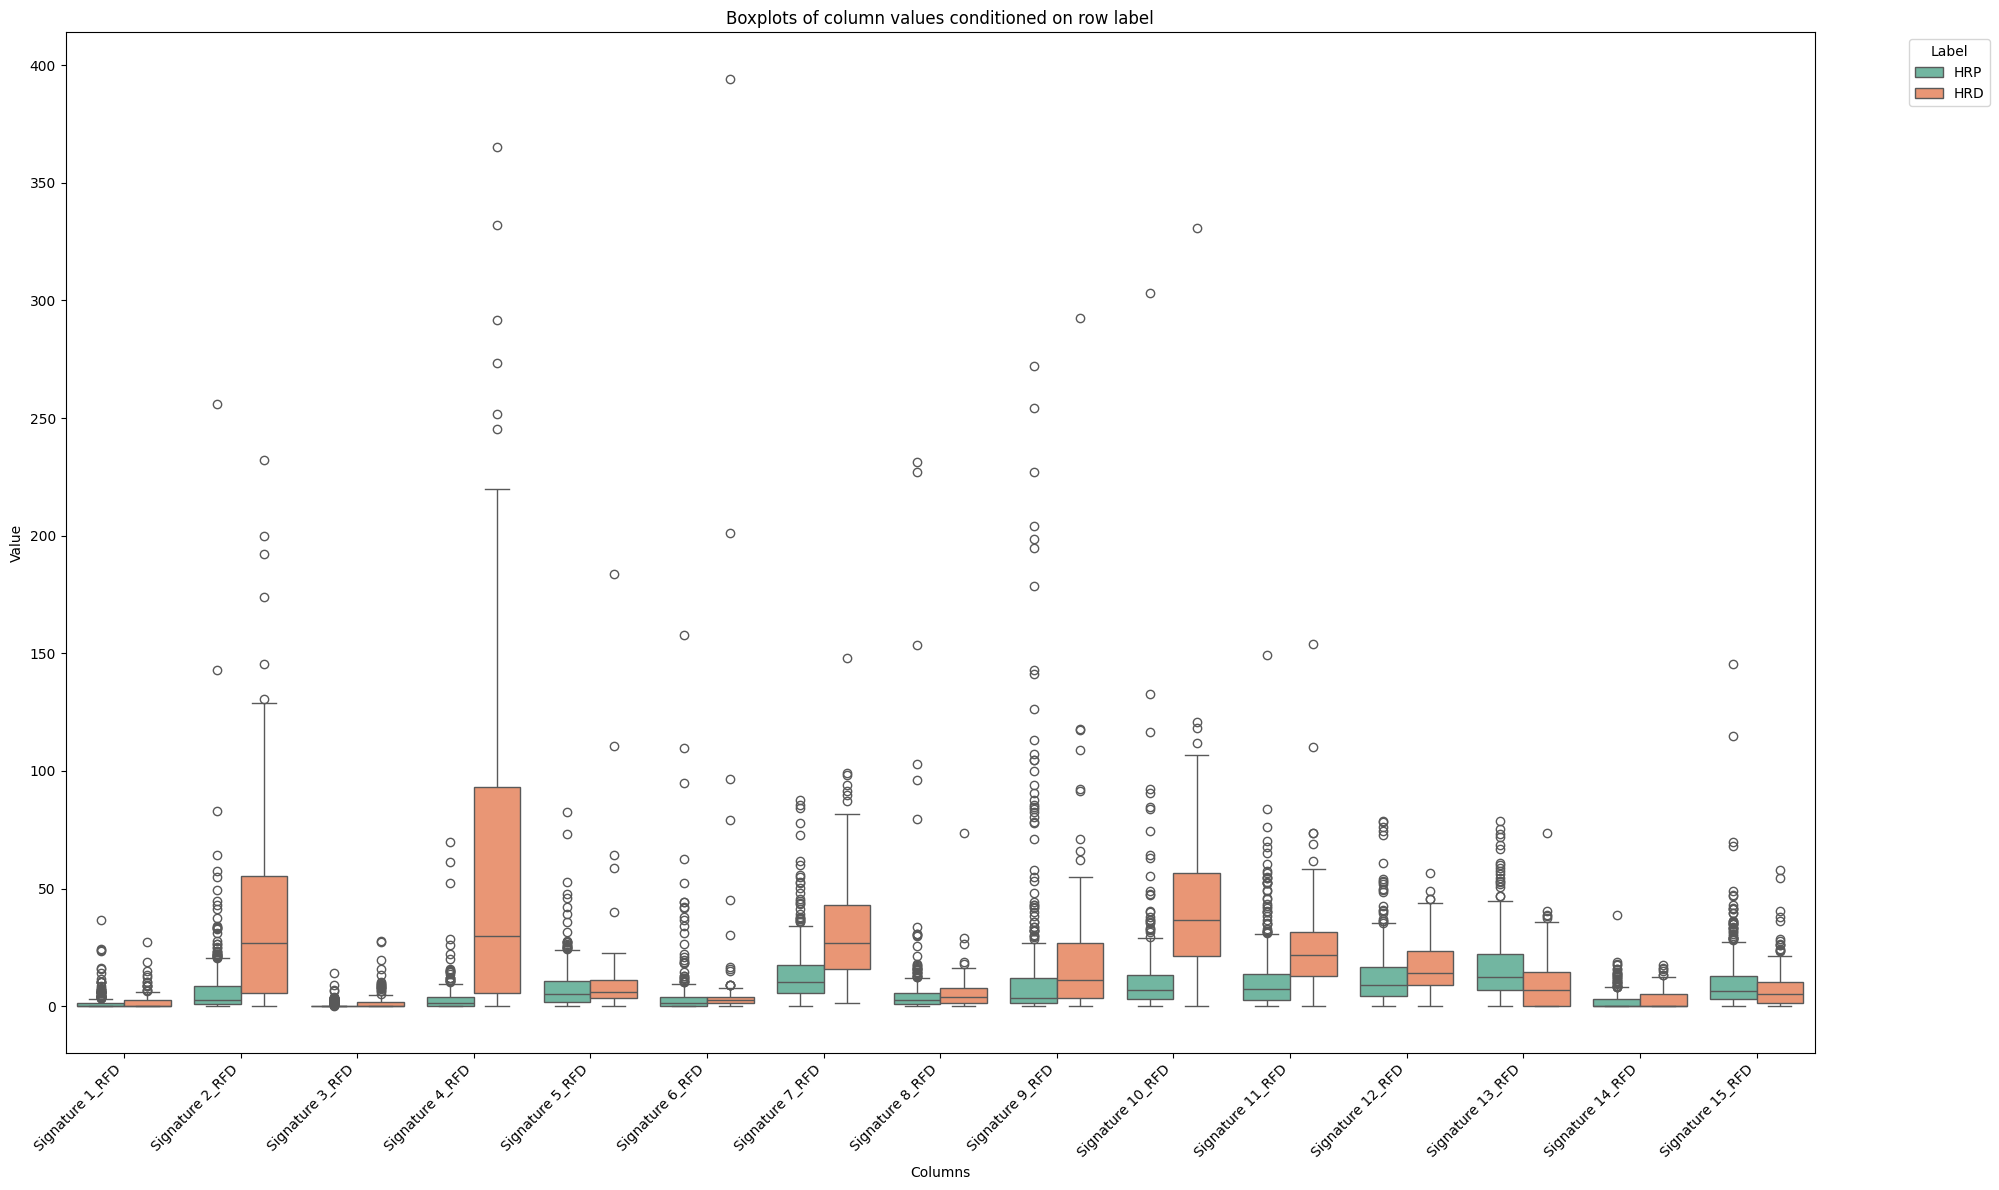

In [69]:
H_sel_norm = H_rfd.T
H_sel_norm=H_sel_norm[H_sel_norm.index.isin(pb_labels.index)]

if labels_fn!=None:
    rowLabels = pb_labels.loc[H_sel_norm.index, 'HRD_label']
    H_sel_labeled = H_sel_norm.copy()
    H_sel_labeled['label'] = rowLabels
    H_long = H_sel_labeled.melt(id_vars='label', var_name='column', value_name='value')
    
    plt.figure(figsize=(20, 12))
    
    sns.boxplot(
        data=H_long,
        x="column",         # Each column of H_sel
        y="value",          # Its numeric values
        hue="label",        # Conditioned on rowLabels
        palette="Set2"
    )
    
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Columns")
    plt.ylabel("Value")
    plt.title("Boxplots of column values conditioned on row label")
    plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    output_path = f"{output_dir}/signature_boxplots_all_vertical.pdf"
    plt.savefig(output_path, format="pdf")
    print(f"Saved editable PDF: {output_path}")
    plt.show()